In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
drug_data = pd.read_csv('Drug_Consumption.csv')

In [4]:
drug_data.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,2,25-34,M,Doctorate degree,UK,White,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
1,3,35-44,M,Professional certificate/ diploma,UK,White,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
2,4,18-24,F,Masters degree,UK,White,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
3,5,35-44,F,Doctorate degree,UK,White,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
4,6,65+,F,Left school at 18 years,Canada,White,-0.67825,-0.30033,-1.55521,2.03972,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL6,CL0,CL0


In [5]:
drug_data.columns

Index(['ID', 'Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore',
       'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'SS', 'Alcohol',
       'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc', 'Coke', 'Crack',
       'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD', 'Meth', 'Mushrooms',
       'Nicotine', 'Semer', 'VSA'],
      dtype='object')

In [6]:
print(drug_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1884 non-null   int64  
 1   Age        1884 non-null   object 
 2   Gender     1884 non-null   object 
 3   Education  1884 non-null   object 
 4   Country    1884 non-null   object 
 5   Ethnicity  1884 non-null   object 
 6   Nscore     1884 non-null   float64
 7   Escore     1884 non-null   float64
 8   Oscore     1884 non-null   float64
 9   AScore     1884 non-null   float64
 10  Cscore     1884 non-null   float64
 11  Impulsive  1884 non-null   float64
 12  SS         1884 non-null   float64
 13  Alcohol    1884 non-null   object 
 14  Amphet     1884 non-null   object 
 15  Amyl       1884 non-null   object 
 16  Benzos     1884 non-null   object 
 17  Caff       1884 non-null   object 
 18  Cannabis   1884 non-null   object 
 19  Choc       1884 non-null   object 
 20  Coke    

In [7]:
drug_data.isnull().sum()

ID           0
Age          0
Gender       0
Education    0
Country      0
Ethnicity    0
Nscore       0
Escore       0
Oscore       0
AScore       0
Cscore       0
Impulsive    0
SS           0
Alcohol      0
Amphet       0
Amyl         0
Benzos       0
Caff         0
Cannabis     0
Choc         0
Coke         0
Crack        0
Ecstasy      0
Heroin       0
Ketamine     0
Legalh       0
LSD          0
Meth         0
Mushrooms    0
Nicotine     0
Semer        0
VSA          0
dtype: int64

In [8]:
drug_data.duplicated().sum()

np.int64(0)

In [9]:
drug_data.drop(['ID'], axis=1, inplace=True)

In [10]:
drug_data.head()

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,Cscore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,25-34,M,Doctorate degree,UK,White,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
1,35-44,M,Professional certificate/ diploma,UK,White,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
2,18-24,F,Masters degree,UK,White,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
3,35-44,F,Doctorate degree,UK,White,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
4,65+,F,Left school at 18 years,Canada,White,-0.67825,-0.30033,-1.55521,2.03972,1.63088,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL6,CL0,CL0


In [11]:
drug_data['Age'].value_counts()

Age
18-24    643
25-34    481
35-44    355
45-54    294
55-64     93
65+       18
Name: count, dtype: int64

In [12]:
drug_data['Age'].unique()

array(['25-34', '35-44', '18-24', '65+', '45-54', '55-64'], dtype=object)

In [13]:
age_mid = {
    '18-24': 21,
    '25-34': 29.5,
    '35-44': 39.5,
    '45-54': 49.5,
    '55-64': 59.5,
    '65+': 70
}

drug_data['Age'] = drug_data['Age'].map(age_mid)

In [14]:
drug_data.head()

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,Cscore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,29.5,M,Doctorate degree,UK,White,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
1,39.5,M,Professional certificate/ diploma,UK,White,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
2,21.0,F,Masters degree,UK,White,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
3,39.5,F,Doctorate degree,UK,White,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
4,70.0,F,Left school at 18 years,Canada,White,-0.67825,-0.30033,-1.55521,2.03972,1.63088,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL6,CL0,CL0


In [15]:
drug_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        1884 non-null   float64
 1   Gender     1884 non-null   object 
 2   Education  1884 non-null   object 
 3   Country    1884 non-null   object 
 4   Ethnicity  1884 non-null   object 
 5   Nscore     1884 non-null   float64
 6   Escore     1884 non-null   float64
 7   Oscore     1884 non-null   float64
 8   AScore     1884 non-null   float64
 9   Cscore     1884 non-null   float64
 10  Impulsive  1884 non-null   float64
 11  SS         1884 non-null   float64
 12  Alcohol    1884 non-null   object 
 13  Amphet     1884 non-null   object 
 14  Amyl       1884 non-null   object 
 15  Benzos     1884 non-null   object 
 16  Caff       1884 non-null   object 
 17  Cannabis   1884 non-null   object 
 18  Choc       1884 non-null   object 
 19  Coke       1884 non-null   object 
 20  Crack   

In [16]:
drug_data['Gender'].value_counts()

Gender
M    943
F    941
Name: count, dtype: int64

In [17]:
drug_data['Country'].value_counts()

Country
UK                     1043
USA                     557
Other                   118
Canada                   87
Australia                54
Republic of Ireland      20
New Zealand               5
Name: count, dtype: int64

In [18]:
drug_data["Country"] = drug_data["Country"].replace("New Zealand", "Other")
drug_data["Country"] = drug_data["Country"].replace("Republic of Ireland", "Other")

In [19]:
drug_data['Country'].value_counts()

Country
UK           1043
USA           557
Other         143
Canada         87
Australia      54
Name: count, dtype: int64

In [20]:
drug_data['Education'].value_counts()

Education
Some college or university, no certificate or degree    506
University degree                                       480
Masters degree                                          283
Professional certificate/ diploma                       269
Left school at 18 years                                 100
Left school at 16 years                                  99
Doctorate degree                                         89
Left school at 17 years                                  30
Left school before 16 years                              28
Name: count, dtype: int64

In [21]:
drug_data['Ethnicity'].value_counts()

Ethnicity
White                1720
Other                  63
Black                  33
Asian                  26
Mixed-White/Black      20
Mixed-White/Asian      19
Mixed-Black/Asian       3
Name: count, dtype: int64

In [22]:
mixed = [
    "Mixed-White/Black",
    "Mixed-White/Asian",
    "Mixed-Black/Asian"
]
drug_data["Ethnicity"] = drug_data["Ethnicity"].replace(mixed, "Mixed")

In [23]:
rare = ["Black", "Asian"]
drug_data["Ethnicity"] = drug_data["Ethnicity"].replace(rare, "Other")

In [24]:
drug_data['Ethnicity'].value_counts()

Ethnicity
White    1720
Other     122
Mixed      42
Name: count, dtype: int64

In [25]:
y = drug_data['Cannabis']

In [26]:
pd.DataFrame(y)

,Cannabis
0,CL4
1,CL3
2,CL2
3,CL3
4,CL0
...,...
1879,CL5
1880,CL3
1881,CL6
1882,CL6


1. CL0 → Never used
2. CL1 → Used over a decade ago
3. CL2 → Used in last decade
4. CL3 → Used in last year
5. CL4 → Used in last month
6. CL5 → Used in last week
7. CL6 → Used in last day

In [27]:
mapping = {
    'CL0': 0, 'CL1': 0, 'CL2': 0,   # Not addicted
    'CL3': 1, 'CL4': 1,            # Mildly addicted
    'CL5': 2, 'CL6': 2             # Addicted
}

y = y.map(mapping)

In [28]:
y.value_counts()

Cannabis
0    885
2    648
1    351
Name: count, dtype: int64

In [29]:
y

0       1
1       1
2       0
3       1
4       0
       ..
1879    2
1880    1
1881    2
1882    2
1883    1
Name: Cannabis, Length: 1884, dtype: int64

In [30]:
X = drug_data.iloc[:,:12]


In [31]:
X['Nicotine_user'] = drug_data['Nicotine'].apply(lambda x: 0 if x in ['CL0','CL1','CL2'] else 1)

In [32]:
X['Coke_user'] = drug_data['Coke'].apply(lambda x: 0 if x in ['CL0','CL1','CL2'] else 1)

In [33]:
X['Ecstasy_user'] = drug_data['Ecstasy'].apply(lambda x: 0 if x in ['CL0','CL1','CL2'] else 1)

In [34]:
X['Alcohol_user'] = drug_data['Alcohol'].apply(lambda x: 0 if x in ['CL0','CL1','CL2'] else 1)

In [35]:
X.head()

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,Cscore,Impulsive,SS,Nicotine_user,Coke_user,Ecstasy_user,Alcohol_user
0,29.5,M,Doctorate degree,UK,White,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,1,1,1,1
1,39.5,M,Professional certificate/ diploma,UK,White,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,0,0,0,1
2,21.0,F,Masters degree,UK,White,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,0,0,0,1
3,39.5,F,Doctorate degree,UK,White,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,0,0,0,1
4,70.0,F,Left school at 18 years,Canada,White,-0.67825,-0.30033,-1.55521,2.03972,1.63088,-1.37983,-1.54858,1,0,0,0


In [36]:
education_map = {
    "Left school before 16 years": 0,
    "Left school at 16 years": 1,
    "Left school at 17 years": 2,
    "Left school at 18 years": 3,
    "Some college or university, no certificate or degree": 4,
    "Professional certificate/ diploma": 5,
    "University degree": 6,
    "Masters degree": 7,
    "Doctorate degree": 8
}

In [37]:
X["Education"] = X["Education"].map(education_map)

In [38]:
X.head()

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,Cscore,Impulsive,SS,Nicotine_user,Coke_user,Ecstasy_user,Alcohol_user
0,29.5,M,8,UK,White,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,1,1,1,1
1,39.5,M,5,UK,White,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,0,0,0,1
2,21.0,F,7,UK,White,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,0,0,0,1
3,39.5,F,8,UK,White,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,0,0,0,1
4,70.0,F,3,Canada,White,-0.67825,-0.30033,-1.55521,2.03972,1.63088,-1.37983,-1.54858,1,0,0,0


In [39]:
X['Gender'] = np.where(X['Gender'].str.contains("M"),0,1)

In [40]:
X.head()

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,Cscore,Impulsive,SS,Nicotine_user,Coke_user,Ecstasy_user,Alcohol_user
0,29.5,0,8,UK,White,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,1,1,1,1
1,39.5,0,5,UK,White,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,0,0,0,1
2,21.0,1,7,UK,White,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,0,0,0,1
3,39.5,1,8,UK,White,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,0,0,0,1
4,70.0,1,3,Canada,White,-0.67825,-0.30033,-1.55521,2.03972,1.63088,-1.37983,-1.54858,1,0,0,0


In [41]:
print(X.shape)
print(y.shape)

(1884, 16)
(1884,)


In [42]:
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

df = X.copy()
df["label"] = y

In [43]:
df.head()

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,AScore,Cscore,Impulsive,SS,Nicotine_user,Coke_user,Ecstasy_user,Alcohol_user,label
0,29.5,0,8,UK,White,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,1,1,1,1,1
1,39.5,0,5,UK,White,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,0,0,0,1,1
2,21.0,1,7,UK,White,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,0,0,0,1,0
3,39.5,1,8,UK,White,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,0,0,0,1,1
4,70.0,1,3,Canada,White,-0.67825,-0.30033,-1.55521,2.03972,1.63088,-1.37983,-1.54858,1,0,0,0,0


In [44]:
df.describe()

,Age,Gender,Education,Nscore,Escore,Oscore,AScore,Cscore,Impulsive,SS,Nicotine_user,Coke_user,Ecstasy_user,Alcohol_user,label
count,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000
mean,33.472134,0.499469,4.989915,-0.000119,0.000143,-0.000225,0.000242,-0.000383,0.007335,-0.002667,0.562633,0.221338,0.274416,0.927813,0.874204
std,12.260576,0.500132,1.766029,0.998345,0.997625,0.996402,0.997481,0.997787,0.954674,0.963575,0.496193,0.415257,0.446338,0.258866,0.893473
min,21.000000,0.000000,0.000000,-3.464360,-3.273930,-3.273930,-3.464360,-3.464360,-2.555240,-2.078480,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,4.000000,-0.678250,-0.695090,-0.717270,-0.606330,-0.652530,-0.711260,-0.525930,0.000000,0.000000,0.000000,1.000000,0.000000
50%,29.500000,0.000000,5.000000,0.042570,0.003320,-0.019280,-0.017290,-0.006650,-0.217120,0.079870,1.000000,0.000000,0.000000,1.000000,1.000000
75%,39.500000,1.000000,6.000000,0.629670,0.637790,0.723300,0.760960,0.584890,0.529750,0.765400,1.000000,0.000000,1.000000,1.000000,2.000000
max,70.000000,1.000000,8.000000,3.273930,3.273930,2.901610,3.464360,3.464360,2.901610,1.921730,1.000000,1.000000,1.000000,1.000000,2.000000


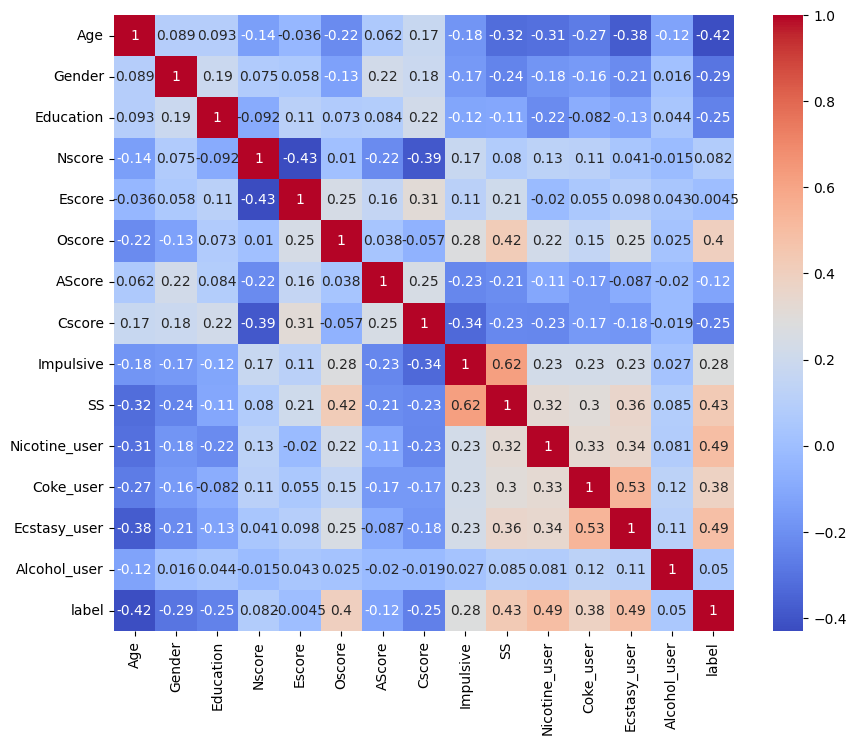

In [45]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

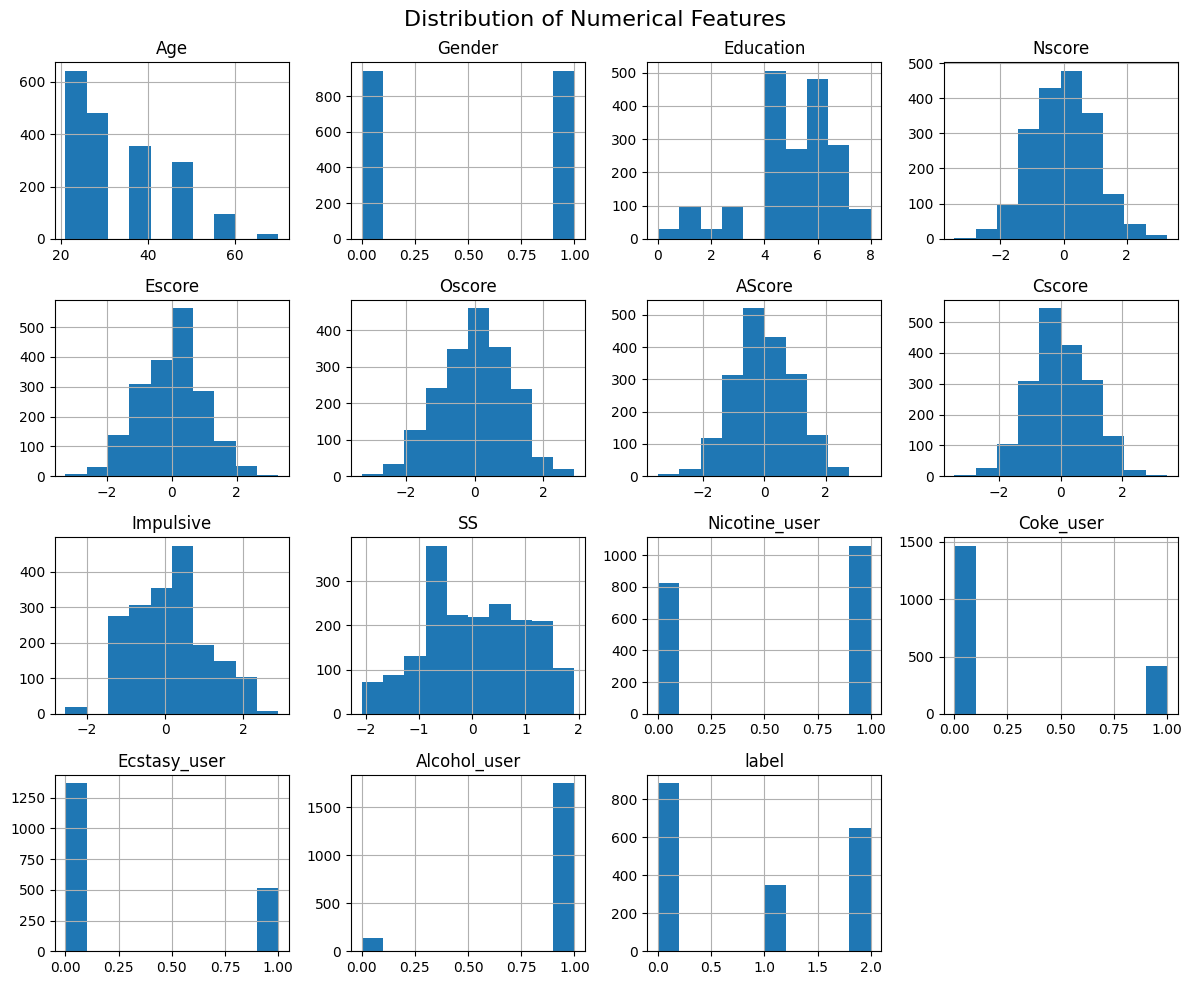

In [46]:
df.hist(figsize=(12,10))
plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()
plt.show()

<Axes: xlabel='label', ylabel='count'>

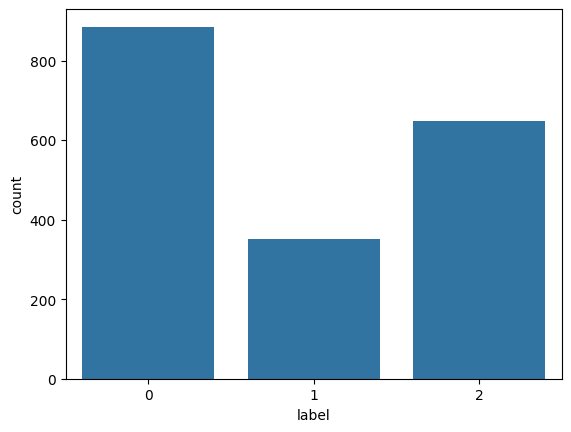

In [47]:
sns.countplot(x='label', data=df)

<Axes: xlabel='Gender', ylabel='count'>

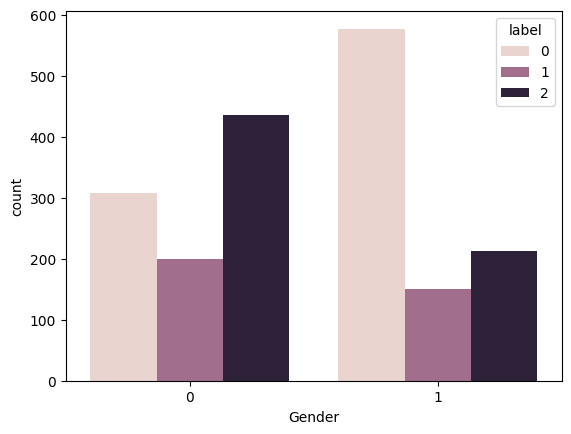

In [48]:
sns.countplot(x='Gender', hue='label', data=df)

<Axes: xlabel='Education', ylabel='count'>

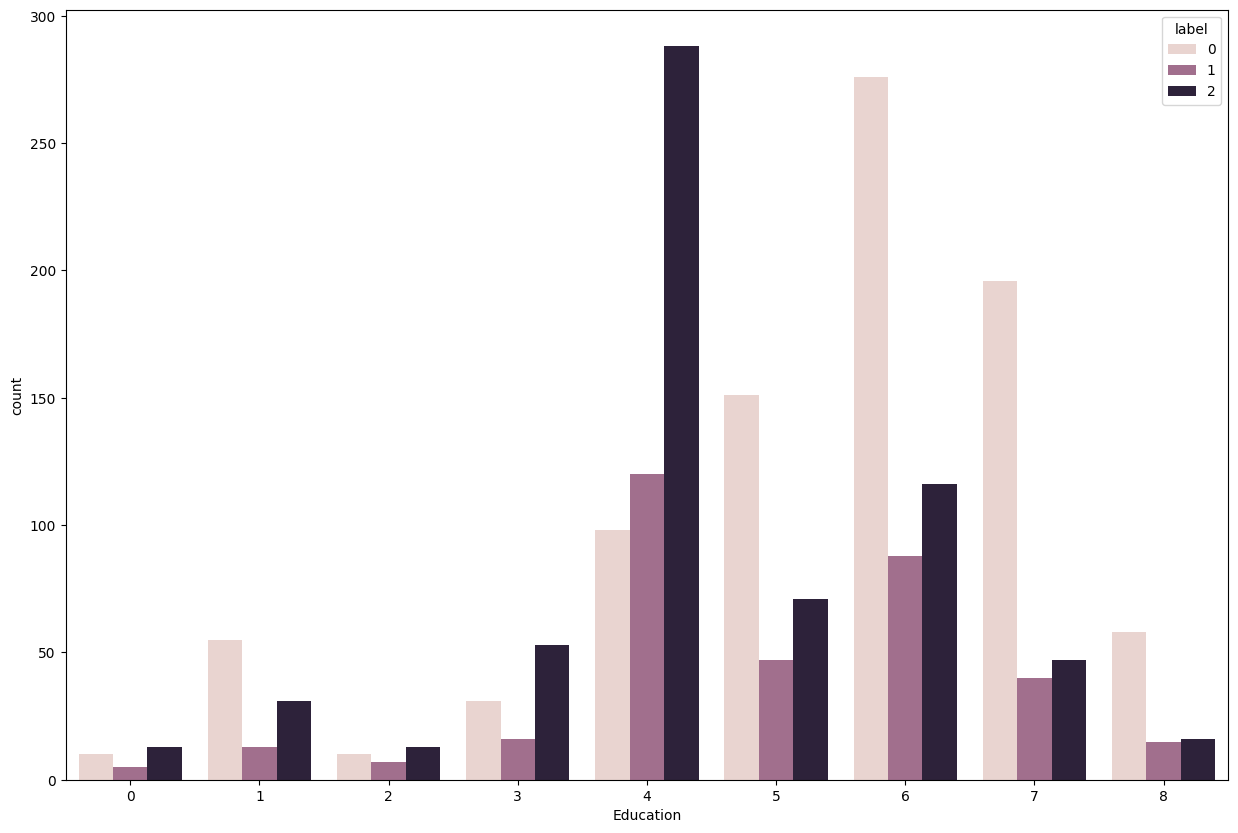

In [49]:
plt.figure(figsize=(15,10))
sns.countplot(x='Education', hue='label', data=df)

<Axes: xlabel='Country', ylabel='count'>

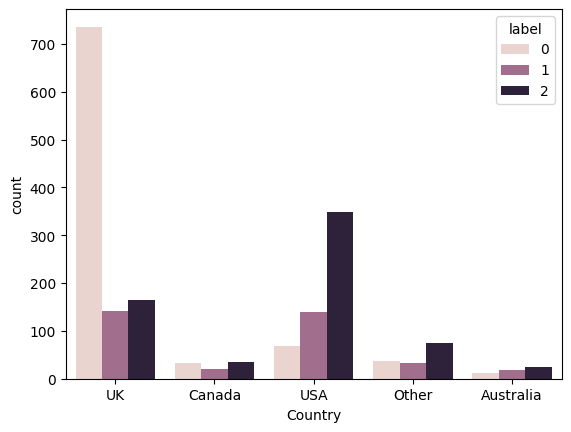

In [50]:
sns.countplot(x='Country', hue='label', data=df)

<Axes: xlabel='Ethnicity', ylabel='count'>

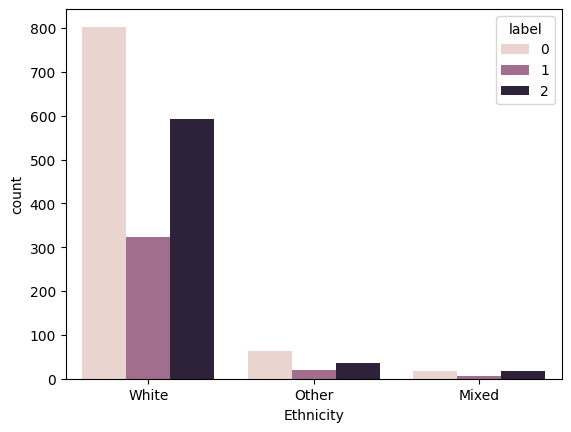

In [51]:
sns.countplot(x='Ethnicity', hue='label', data=df)

<Axes: xlabel='label', ylabel='Age'>

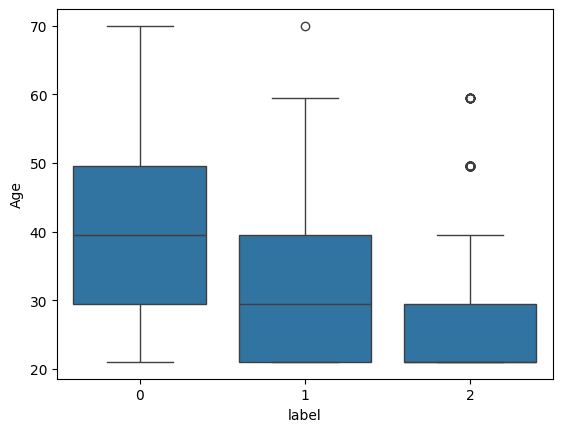

In [52]:
sns.boxplot(x='label', y='Age', data=df)

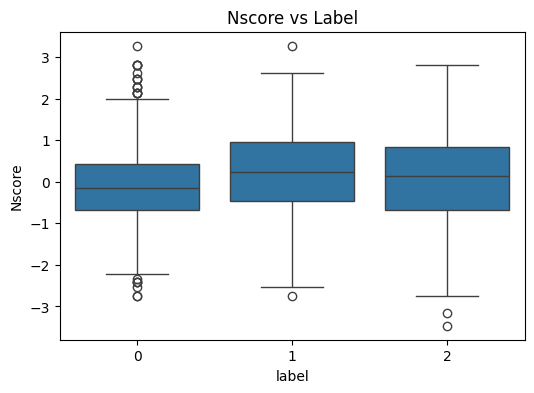

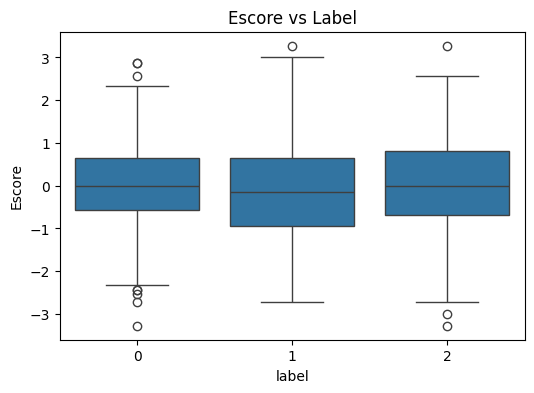

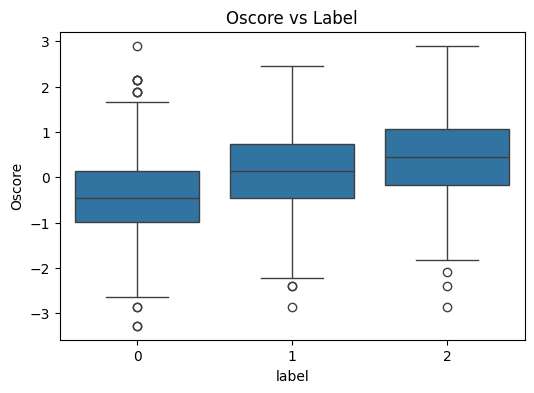

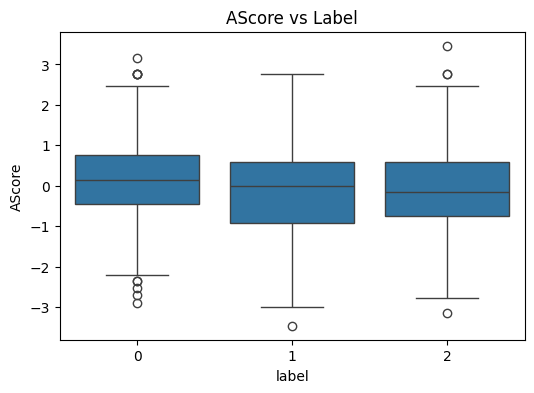

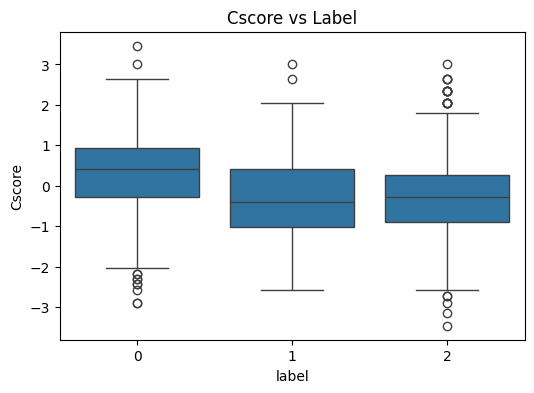

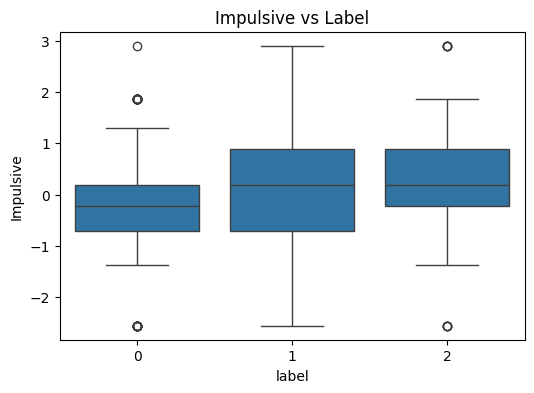

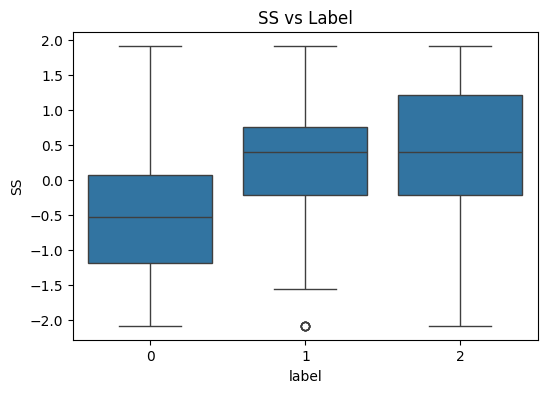

In [53]:
features = ['Nscore','Escore','Oscore','AScore','Cscore','Impulsive','SS']

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f"{col} vs Label")
    plt.show()

In [54]:
X.drop(['Escore', 'AScore' , 'Nscore'], axis=1, inplace=True)

In [55]:
df.columns

Index(['Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore',
       'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'SS',
       'Nicotine_user', 'Coke_user', 'Ecstasy_user', 'Alcohol_user', 'label'],
      dtype='object')

In [56]:
X

,Age,Gender,Education,Country,Ethnicity,Oscore,Cscore,Impulsive,SS,Nicotine_user,Coke_user,Ecstasy_user,Alcohol_user
0,29.5,0,8,UK,White,1.43533,-0.14277,-0.71126,-0.21575,1,1,1,1
1,39.5,0,5,UK,White,-0.84732,-1.01450,-1.37983,0.40148,0,0,0,1
2,21.0,1,7,UK,White,-0.01928,0.58489,-1.37983,-1.18084,0,0,0,1
3,39.5,1,8,UK,White,-0.45174,1.30612,-0.21712,-0.21575,0,0,0,1
4,70.0,1,3,Canada,White,-1.55521,1.63088,-1.37983,-1.54858,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879,21.0,1,4,USA,White,1.88511,-1.13788,0.88113,1.92173,0,0,0,1
1880,21.0,0,4,USA,White,0.58331,-1.51840,0.88113,0.76540,1,0,0,1
1881,29.5,1,6,USA,White,-1.27553,-1.38502,0.52975,-0.52593,1,1,1,1
1882,21.0,1,4,USA,White,0.29338,-2.57309,1.29221,1.22470,1,0,1,1


In [57]:
y.value_counts()

Cannabis
0    885
2    648
1    351
Name: count, dtype: int64

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,  stratify=y)
# why we use  stratify=y

In [59]:
print(X_train.dtypes)

Age              float64
Gender             int64
Education          int64
Country           object
Ethnicity         object
Oscore           float64
Cscore           float64
Impulsive        float64
SS               float64
Nicotine_user      int64
Coke_user          int64
Ecstasy_user       int64
Alcohol_user       int64
dtype: object


In [60]:
cat_feature = X.select_dtypes(include='object').columns
num_feature = X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_feature),
        ("StandardScaler", numeric_transformer, num_feature)
    ]
)

In [61]:
preprocessor

,transformers,"[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [62]:
X_train = preprocessor.fit_transform(X_train)

In [63]:
X_test = preprocessor.transform(X_test)

In [64]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.0,0.0,1.0,0.0,0.0,1.0,0.498281,0.994046,-2.287638,-0.466019,0.576809,-1.471144,-0.556698,-1.131317,-0.525392,-0.604182,0.286073
1,0.0,1.0,0.0,0.0,0.0,1.0,-0.313118,-1.005990,-2.287638,0.870494,-0.795356,-0.244960,0.081311,0.883925,-0.525392,-0.604182,0.286073
2,0.0,0.0,0.0,1.0,0.0,1.0,1.309681,-1.005990,0.557749,2.438420,1.301060,-1.471144,0.081311,0.883925,-0.525392,1.655130,-3.495611
3,0.0,0.0,1.0,0.0,0.0,1.0,-1.002808,0.994046,1.126826,-0.862099,0.750945,0.187212,-0.556698,-1.131317,-0.525392,-0.604182,0.286073
4,0.0,0.0,0.0,1.0,0.0,1.0,-1.002808,-1.005990,-0.580406,0.432703,-1.535293,0.913246,2.021101,0.883925,-0.525392,1.655130,0.286073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1502,0.0,0.0,1.0,0.0,0.0,1.0,-0.313118,0.994046,1.695903,-0.191724,0.750945,-0.766076,-0.556698,-1.131317,-0.525392,-0.604182,0.286073
1503,0.0,0.0,0.0,1.0,0.0,1.0,-1.002808,0.994046,-0.580406,0.870494,-0.153900,-0.766076,0.420021,-1.131317,-0.525392,-0.604182,0.286073
1504,0.0,0.0,0.0,0.0,0.0,1.0,-1.002808,-1.005990,0.557749,0.870494,-0.795356,1.346767,0.803290,0.883925,-0.525392,1.655130,0.286073
1505,0.0,0.0,1.0,0.0,0.0,1.0,0.498281,0.994046,-0.580406,0.280040,-0.017210,0.187212,-0.894176,0.883925,-0.525392,-0.604182,-3.495611


In [65]:
pd.DataFrame(X_test)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.0,0.0,1.0,0.0,0.0,1.0,0.498281,-1.005990,1.695903,-1.570882,0.576809,-2.710722,-0.894176,0.883925,1.903339,1.655130,0.286073
1,0.0,0.0,0.0,1.0,0.0,1.0,-1.002808,0.994046,-0.580406,1.873779,-1.153179,0.913246,2.021101,-1.131317,-0.525392,-0.604182,0.286073
2,0.0,0.0,0.0,1.0,0.0,1.0,-1.002808,-1.005990,-0.580406,-0.033014,-1.029282,0.913246,0.803290,0.883925,-0.525392,1.655130,0.286073
3,0.0,0.0,1.0,0.0,0.0,1.0,0.498281,0.994046,1.126826,1.050011,0.750945,0.187212,0.420021,-1.131317,-0.525392,-0.604182,0.286073
4,0.0,0.0,1.0,0.0,0.0,1.0,-1.002808,0.994046,-0.580406,-1.134141,0.250086,-0.244960,0.420021,0.883925,1.903339,-0.604182,0.286073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,0.0,0.0,1.0,0.0,0.0,1.0,-1.002808,0.994046,-0.580406,0.432703,0.932894,-0.766076,0.081311,-1.131317,-0.525392,-0.604182,0.286073
373,0.0,0.0,1.0,0.0,0.0,1.0,-0.313118,0.994046,0.557749,0.570336,-0.153900,1.346767,1.287010,0.883925,-0.525392,-0.604182,0.286073
374,0.0,1.0,0.0,0.0,0.0,1.0,0.498281,0.994046,-2.287638,0.127899,-0.017210,-1.471144,-0.894176,-1.131317,-0.525392,-0.604182,0.286073
375,0.0,0.0,1.0,0.0,0.0,1.0,1.309681,-1.005990,-0.011329,-1.570882,0.113295,-1.471144,-1.633721,-1.131317,-0.525392,-0.604182,0.286073


In [66]:
pd.DataFrame(y_test)

,Cannabis
625,2
1879,2
1116,2
254,0
370,1
...,...
670,0
1707,0
30,0
1729,0


In [67]:
pd.DataFrame(y_train)

,Cannabis
1576,0
496,2
1011,1
448,0
1750,2
...,...
1450,0
1541,2
786,2
388,0


In [68]:
print(y_train.value_counts())

Cannabis
0    708
2    518
1    281
Name: count, dtype: int64


In [69]:
from imblearn.over_sampling import SMOTE

In [70]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_resampled))

Before SMOTE: [708 281 518]
After SMOTE : [708 708 708]


In [71]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, \
                            recall_score, f1_score, roc_auc_score, roc_curve

In [72]:
models = {
    "SVM" : SVC(probability=True),
    "Naive Bayes" : GaussianNB(),
    "KNN" : KNeighborsClassifier(),
    "AdaBoost" : AdaBoostClassifier(),
    "Gradient Boosting" : GradientBoostingClassifier(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_split=10),
    "Logistic Regression": LogisticRegression(max_iter=1000,class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100,max_depth=5,min_samples_split=10),
    "Xgboost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',   max_depth=3,learning_rate=0.1,n_estimators=100)
}

for name, model in models.items():

    model.fit(X_train_resampled, y_train_resampled)

    # Predictions
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)

    # Probabilities
    y_train_prob = model.predict_proba(X_train_resampled)
    y_test_prob = model.predict_proba(X_test)

    # Train metrics
    model_train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
    model_train_precision = precision_score(y_train_resampled, y_train_pred, average='macro', zero_division=0)
    model_train_recall = recall_score(y_train_resampled, y_train_pred, average='macro')
    model_train_f1 = f1_score(y_train_resampled, y_train_pred, average='macro')

    model_train_rocauc_score = roc_auc_score(
        y_train_resampled, y_train_prob, multi_class='ovr'
    )

    # Test metrics
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    model_test_recall = recall_score(y_test, y_test_pred, average='macro')
    model_test_f1 = f1_score(y_test, y_test_pred, average='macro')

    model_test_rocauc_score = roc_auc_score(
        y_test, y_test_prob, multi_class='ovr'
    )

    print(name)

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    print("Overfitting Gap (F1): {:.4f}".format(model_train_f1 - model_test_f1))

    print('='*35)
    print('\n')

SVM
Model performance for Training set
- Accuracy: 0.7834
- F1 score: 0.7832
- Precision: 0.7833
- Recall: 0.7834
- Roc Auc Score: 0.9237
----------------------------------
Model performance for Test set
- Accuracy: 0.6340
- F1 score: 0.5838
- Precision: 0.5876
- Recall: 0.5860
- Roc Auc Score: 0.8089
Overfitting Gap (F1): 0.1994


Naive Bayes
Model performance for Training set
- Accuracy: 0.6295
- F1 score: 0.6231
- Precision: 0.6206
- Recall: 0.6295
- Roc Auc Score: 0.8134
----------------------------------
Model performance for Test set
- Accuracy: 0.6127
- F1 score: 0.5676
- Precision: 0.5830
- Recall: 0.5751
- Roc Auc Score: 0.7928
Overfitting Gap (F1): 0.0555


KNN
Model performance for Training set
- Accuracy: 0.8319
- F1 score: 0.8318
- Precision: 0.8423
- Recall: 0.8319
- Roc Auc Score: 0.9617
----------------------------------
Model performance for Test set
- Accuracy: 0.5968
- F1 score: 0.5568
- Precision: 0.5745
- Recall: 0.5675
- Roc Auc Score: 0.7736
Overfitting Gap (F1):

/Users/gouravsaini1316/Desktop/AI/PYTHON/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:57:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [73]:
svm_params = {
    'C': [0.1, 1, 0.5, 0.3, 2],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf', 'linear']
}
logistic_params = {
    'C': [0.1, 1, 0.5, 2],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'class_weight': ['balanced']
}

In [74]:
randomcv_models = [
                   ("SVM", SVC(probability=True), svm_params),
                   ("Logestic", LogisticRegression(), logistic_params)  
                   ]

In [75]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train_resampled, y_train_resampled)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/gouravsaini1316/Desktop/AI/PYTHON/venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=100. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.2s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.2s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.3s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.4s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.4s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.4s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.2s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.4s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.2s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.2s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   0.3s
[CV] END ...................

/Users/gouravsaini1316/Desktop/AI/PYTHON/venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=100. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [76]:
models = {
    "SVM" : SVC(kernel = 'rbf', gamma = 'scale' , C = 2 , probability=True,class_weight='balanced'),
    "logistic" : LogisticRegression(solver = 'lbfgs', penalty = 'l2', class_weight = 'balanced', C = 0.1)
}

for name, model in models.items():

    model.fit(X_train_resampled, y_train_resampled)

    # Predictions
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)

    # Probabilities
    y_train_prob = model.predict_proba(X_train_resampled)
    y_test_prob = model.predict_proba(X_test)

    # Train metrics
    model_train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
    model_train_precision = precision_score(y_train_resampled, y_train_pred, average='macro', zero_division=0)
    model_train_recall = recall_score(y_train_resampled, y_train_pred, average='macro')
    model_train_f1 = f1_score(y_train_resampled, y_train_pred, average='macro')

    model_train_rocauc_score = roc_auc_score(
        y_train_resampled, y_train_prob, multi_class='ovr'
    )

    # Test metrics
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    model_test_recall = recall_score(y_test, y_test_pred, average='macro')
    model_test_f1 = f1_score(y_test, y_test_pred, average='macro')

    model_test_rocauc_score = roc_auc_score(
        y_test, y_test_prob, multi_class='ovr'
    )

    print(name)

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    print("Overfitting Gap (F1): {:.4f}".format(model_train_f1 - model_test_f1))

    print('='*35)
    print('\n')

SVM
Model performance for Training set
- Accuracy: 0.8324
- F1 score: 0.8326
- Precision: 0.8330
- Recall: 0.8324
- Roc Auc Score: 0.9435
----------------------------------
Model performance for Test set
- Accuracy: 0.6419
- F1 score: 0.5902
- Precision: 0.5927
- Recall: 0.5923
- Roc Auc Score: 0.7989
Overfitting Gap (F1): 0.2424


logistic
Model performance for Training set
- Accuracy: 0.6295
- F1 score: 0.6211
- Precision: 0.6183
- Recall: 0.6295
- Roc Auc Score: 0.8277
----------------------------------
Model performance for Test set
- Accuracy: 0.6578
- F1 score: 0.5991
- Precision: 0.6005
- Recall: 0.5999
- Roc Auc Score: 0.8187
Overfitting Gap (F1): 0.0221


